<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>

</font>
<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Deep Generative Models
</font>

<hr/>
<font color="#800080" size=5>
Assignment 1
<br>
</font>
<font size=5>
Instructor: Dr. S. Amini
<br>
</font>
<font size=4>
Fall 2024
<br>
</font>
<font face="Times New Roman" size=4>
Deadline: Month day at 23:55
</font>
<hr>
</div></font>

It is recommended to open this notebook in Google Colab from [here](https://colab.research.google.com/drive/1tPrFiVeEtt76GIoImPOuv7NA9hKorlue?usp=sharing) and create a copy. You can comment your questions on the notebook as well.

In this exercise we want to gain hands-on experience with Normalizing Flow Models.
1. We want to implement a simple flow model from scratch. (GPU not required)
2. We will use a flow model to perform image in-painting. (GPU recommended)

# Section 1: Flow From Scratch

In [ ]:
# @title imports
import torch
import torch.nn as nn
from torch.nn import functional as F

import torch.optim as optim
import torch.distributions as D

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import seaborn as sns
import torchvision as tv

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # you can change this if you like
print(device)

cuda


One of the challenges in creating flow models is creating invertible transformations. Also we would like it if computation of their inverse and/or the log determinant of their jacobian were simple.

In [ ]:
# @title base transform abstract class

class InverseNotAvailable(Exception):
    """Exception to be thrown when a transform does not have an inverse."""

    pass

class Transform(nn.Module):
    """Base class for all transform objects."""

    def forward(self, inputs, context=None):
        raise NotImplementedError()

    def inverse(self, inputs, context=None):
        raise InverseNotAvailable()


First we can create a random permutation transform

In [ ]:
class PermutationTransform(Transform):
    def __init__(self, num_features):
        super().__init__()
        permutation = torch.randperm(num_features)
        self.register_buffer('permutation', permutation)
        self.register_buffer('inverse_permutation', torch.argsort(permutation))

    def forward(self, inputs, context=None):
        return inputs[:, self.permutation], 0  # Log-det is zero

    def inverse(self, inputs, context=None):
        return inputs[:, self.inverse_permutation]

Now  lets create a simple Coupling Transform.

In [ ]:
class CouplingTransform(Transform):
    def __init__(self, mask, hidden_dims, s_net_f=None, t_net_f=None):
        """
        Args:
            mask: a 1-dim tensor, tuple or list. It indexes inputs as follows:
                * If `mask[i] > 0`, `input[i]` will be transformed.
                * If `mask[i] <= 0`, `input[i]` will be passed unchanged.
            hidden_dims: Number of hidden units in the coupling neural networks.
            s_net_f: A function taking (input_dim, output_dim, hidden_dims) returning a Neural Network for Scaling function
            t_net_f: A function taking (input_dim, output_dim, hidden_dims) returning a Neural Network for Translating function
        """
        super(CouplingTransform, self).__init__()

        mask = torch.as_tensor(mask, dtype=torch.float32)
        if mask.dim() != 1:
            raise ValueError("Mask must be a 1-dim tensor.")
        if mask.numel() <= 0:
            raise ValueError("Mask can't be empty.")

        self.register_buffer('mask', mask)

        self.num_features = self.mask.numel()
        features_vector = torch.arange(self.num_features)

        # Create indices for unchanged and transformed features
        self.unchanged_idx = torch.where(mask <= 0)[0]
        self.transformed_idx = torch.where(mask > 0)[0]

        # Determine input dimensions for the networks
        input_dim = len(self.unchanged_idx)
        output_dim = len(self.transformed_idx)

        # Default network creation function if none provided
        if s_net_f is None:
            s_net_f = self._default_net
        if t_net_f is None:
            t_net_f = self._default_net

        # Create scaling and translation networks
        self.s_net = s_net_f(input_dim, output_dim, hidden_dims)
        self.t_net = t_net_f(input_dim, output_dim, hidden_dims)

    def _default_net(self, input_dim, output_dim, hidden_dims):
        """Default neural network architecture"""
        layers = []
        prev_dim = input_dim

        # Add hidden layers
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU())
            prev_dim = h_dim

        # Output layer
        layers.append(nn.Linear(prev_dim, output_dim))

        return nn.Sequential(*layers)

    def _net(self, input_dim, output_dim, hidden_dims):
        """Wrapper for backward compatibility"""
        return self._default_net(input_dim, output_dim, hidden_dims)

    def forward(self, inputs, context=None):
        if inputs.dim() != 2:
            raise ValueError("Inputs must be a 2D tensor.")

        if inputs.shape[1] != self.num_features:
            raise ValueError(
                f"Expected features = {self.num_features}, got {inputs.shape[1]}."
            )

        batch_size = inputs.shape[0]

        # Split input into unchanged and transformed parts
        x_unchanged = inputs[:, self.unchanged_idx]
        x_transformed = inputs[:, self.transformed_idx]

        # Compute scaling and translation parameters from unchanged part
        s = self.s_net(x_unchanged)
        t = self.t_net(x_unchanged)

        # Use tanh to keep scaling factors bounded (as suggested)
        s = torch.tanh(s)

        # Apply affine transformation
        z_transformed = x_transformed * torch.exp(s) + t

        # Compute log determinant of Jacobian
        log_det_J = s.sum(dim=1)

        # Reconstruct the full output
        z = torch.zeros_like(inputs)
        z[:, self.unchanged_idx] = x_unchanged
        z[:, self.transformed_idx] = z_transformed

        return z, log_det_J

    def inverse(self, inputs, context=None):
        if inputs.dim() != 2:
            raise ValueError("Inputs must be a 2D tensor.")

        if inputs.shape[1] != self.num_features:
            raise ValueError(
                f"Expected features = {self.num_features}, got {inputs.shape[1]}."
            )

        batch_size = inputs.shape[0]

        # Split input into unchanged and transformed parts
        z_unchanged = inputs[:, self.unchanged_idx]
        z_transformed = inputs[:, self.transformed_idx]

        # Compute scaling and translation parameters from unchanged part
        s = self.s_net(z_unchanged)
        t = self.t_net(z_unchanged)

        # Use tanh to keep scaling factors bounded
        s = torch.tanh(s)

        # Apply inverse affine transformation
        x_transformed = (z_transformed - t) * torch.exp(-s)

        # Reconstruct the original input
        z = torch.zeros_like(inputs)
        z[:, self.unchanged_idx] = z_unchanged
        z[:, self.transformed_idx] = x_transformed

        return z

In this step we want to implement a simple Normalizing Flow Model similar to RealNVP. First we should create our base flow module. This base module is flexible in that it can have any number of transformations that inherit from the base transformation class.

In [ ]:
class Flow(nn.Module):
    def __init__(self, transforms, base_distribution=None, device='cpu'):
        super(Flow, self).__init__()
        self.device = device
        self.transforms = nn.ModuleList(transforms).to(device)
        self.num_features = self.transforms[0].num_features

        if base_distribution is None:
            self.base_distribution = D.MultivariateNormal(
                loc=torch.zeros(self.num_features, device=device),
                covariance_matrix=torch.eye(self.num_features, device=device)
            )
        else:
            self.base_distribution = base_distribution

    def forward(self, x):
        """Transform data x to latent space z (forward pass)"""
        batch_size = x.shape[0]
        log_det_J = torch.zeros(batch_size, device=x.device)

        # Apply all transformations sequentially
        for transform in self.transforms:
            x, log_det_J_transform = transform(x)
            log_det_J += log_det_J_transform

        return x, log_det_J

    def inverse(self, z):
        """Transform latent z back to data space x (inverse pass)"""
        # Apply transformations in reverse order
        for transform in reversed(self.transforms):
            z = transform.inverse(z)

        return z

    def log_prob(self, x):
        """Compute log probability of data x under the flow model"""
        # Transform data to latent space
        z, log_det_J = self.forward(x)

        # Compute log probability in latent space
        log_prob_z = self.base_distribution.log_prob(z)

        # Apply change of variables formula: log p(x) = log p(z) + log |det J|
        log_prob_x = log_prob_z + log_det_J

        return log_prob_x

    def sample(self, num_samples):
        """Generate samples from the flow model"""
        # Sample from base distribution
        z = self.base_distribution.sample((num_samples,))

        # Transform through inverse pass
        x = self.inverse(z)

        return x

    def sample_and_log_prob(self, num_samples):
        """Generate samples and compute their log probabilities"""
        # Sample from base distribution
        z = self.base_distribution.sample((num_samples,))

        # Compute log probability in latent space
        log_prob_z = self.base_distribution.log_prob(z)

        # Transform through inverse pass
        x = self.inverse(z)

        # Forward pass to get log determinant (needed for log probability)
        _, log_det_J = self.forward(x)

        # Compute log probability using change of variables
        log_prob_x = log_prob_z + log_det_J

        return x, log_prob_x

Now  we initialize the model and coupling layers. We then train the model on the simple Moons dataset and visualize its learning process through its latent space.

In [ ]:
# Utility function to create alternating masks
def create_alternating_masks(num_features, num_masks):
    masks = []
    for i in range(num_masks):
        mask = [(i + j) % 2 for j in range(num_features)]
        masks.append(mask)
    return masks

In [ ]:
# Hyperparameters
num_features = 2
num_layers = 4
hidden_dims = 64
batch_size = 256
learning_rate = 1e-3
num_epochs = 500

Our flow model can be comprised by CouplingTransforms each followed by a PermutationTransform. You are free to use other architectures or implement other transform as long as they are correct.

You may use a Multivariate Normal distribution.

In [ ]:
# Define masks for alternating coupling layers
masks = create_alternating_masks(num_features, num_layers)


# Initialize transforms - just use coupling layers with alternating masks
transforms = []
for i in range(num_layers):
    coupling_layer = CouplingTransform(
        mask=masks[i],
        hidden_dims=[hidden_dims, hidden_dims],  # 2 hidden layers
        s_net_f=None,  # Use default network
        t_net_f=None   # Use default network
    ).to(device)
    transforms.append(coupling_layer)

# Initialize base distribution - standard normal (create it on the target device)
base_dist = D.MultivariateNormal(
    loc=torch.zeros(num_features, device=device),
    covariance_matrix=torch.eye(num_features, device=device)
)


# Initialize Flow model
flow = Flow(transforms=transforms, base_distribution=base_dist).to(device)


Epoch 1/500, Loss: 2.3461


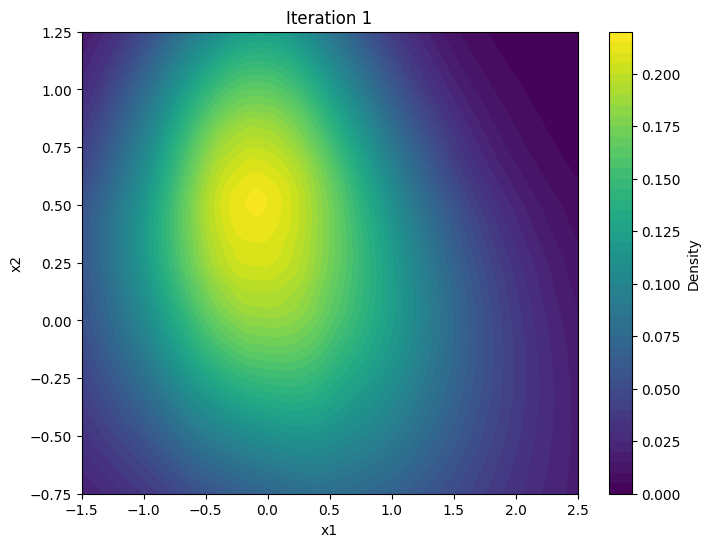

Epoch 100/500, Loss: 1.4224


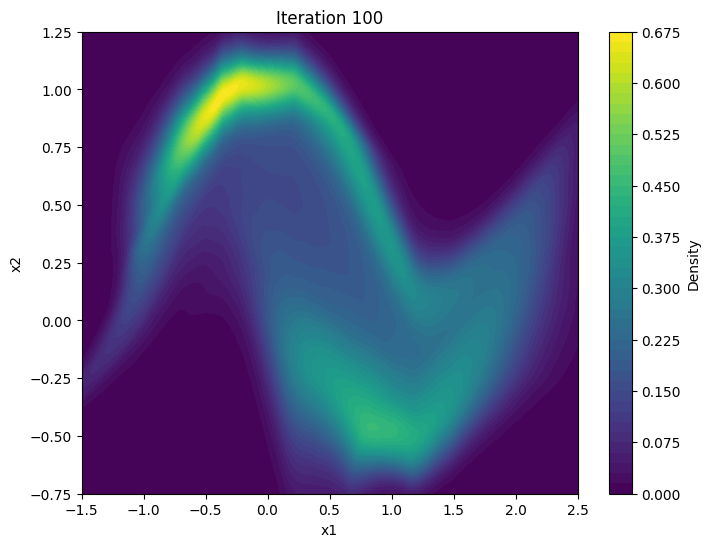

Epoch 200/500, Loss: 1.1416


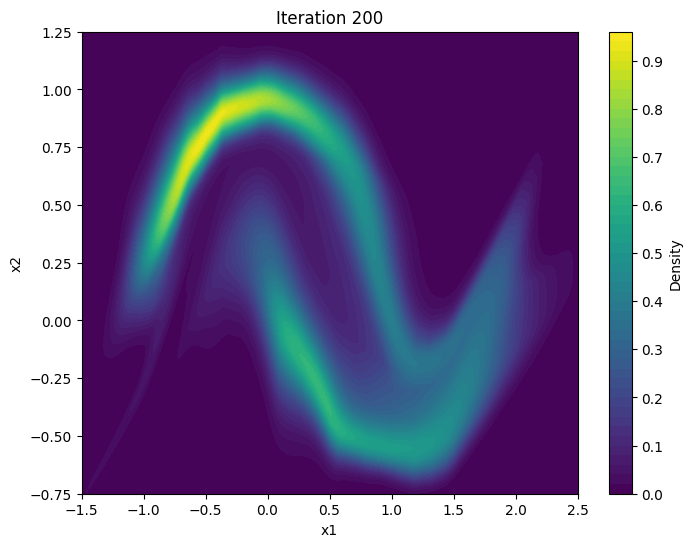

Epoch 300/500, Loss: 1.1225


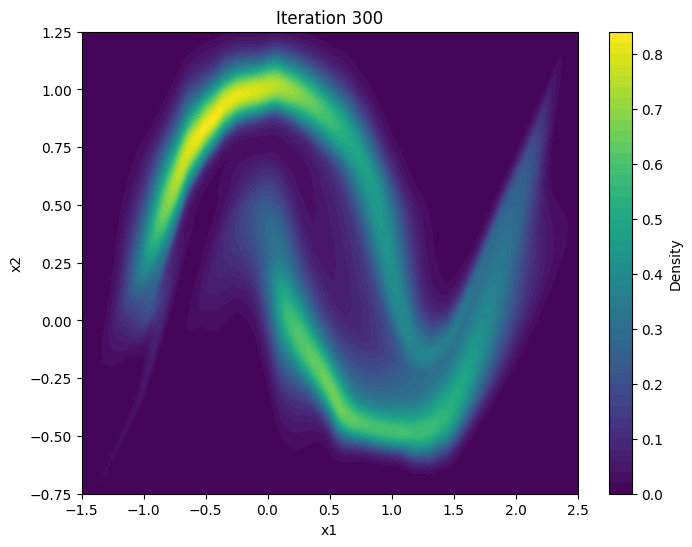

Epoch 400/500, Loss: 1.1152


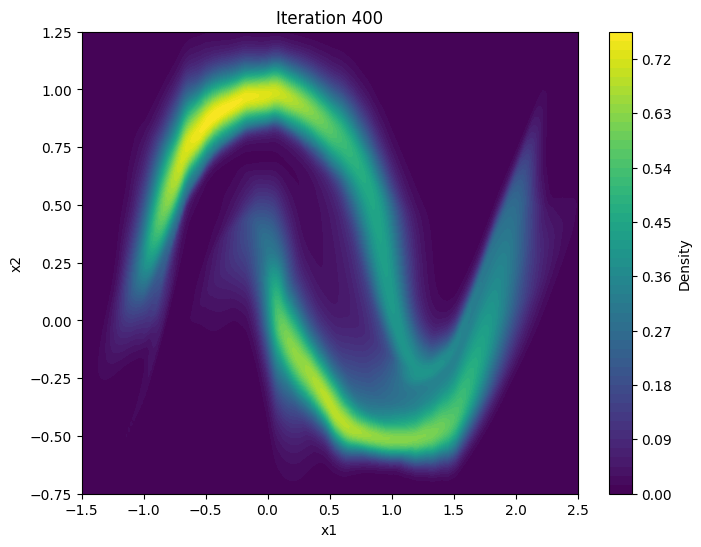

Epoch 500/500, Loss: 1.0791


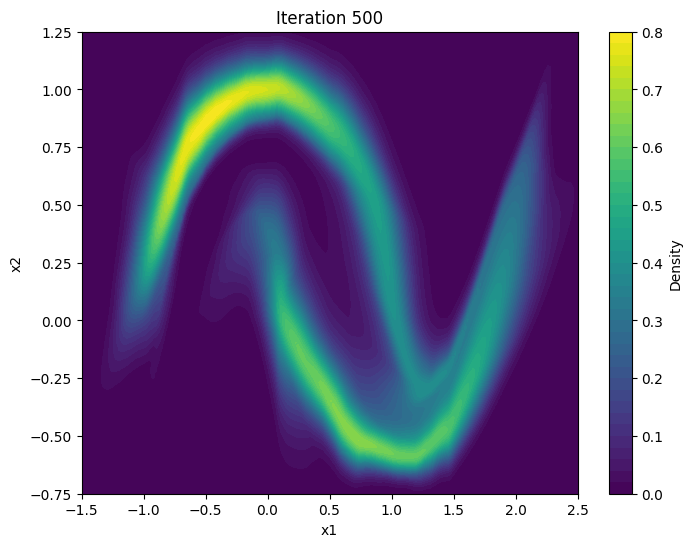

In [ ]:
# Optimizer
optimizer = torch.optim.Adam(flow.parameters(), lr=learning_rate)

# Training loop
for epoch in range(1, num_epochs + 1):
    # Generate batch data
    x, _ = make_moons(n_samples=batch_size, noise=0.1)
    x = torch.tensor(x, dtype=torch.float32).to(device)

    #TODO

    # Zero gradients
    optimizer.zero_grad()

    # Forward pass: compute log probability of data
    log_prob = flow.log_prob(x)

    # Negative log likelihood loss (maximize log prob = minimize negative log prob)
    loss = -log_prob.mean()

    loss.backward()
    optimizer.step()

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{num_epochs}, Loss: {loss.item():.4f}")

        # Visualization of the learned density
        with torch.no_grad():
            xline = torch.linspace(-1.5, 2.5, 200, device=device)
            yline = torch.linspace(-0.75, 1.25, 200, device=device)
            xgrid, ygrid = torch.meshgrid(xline, yline, indexing='ij')
            xyinput = torch.cat([
                xgrid.reshape(-1, 1),
                ygrid.reshape(-1, 1)
            ], dim=1).to(device)

            log_prob_grid = flow.log_prob(xyinput)
            zgrid = torch.exp(log_prob_grid).reshape(200, 200).cpu()

        plt.figure(figsize=(8, 6))
        plt.contourf(
            xgrid.cpu().numpy(),
            ygrid.cpu().numpy(),
            zgrid.numpy(),
            levels=50,
            cmap='viridis'
        )
        plt.title(f'Iteration {epoch}')
        plt.xlabel('x1')
        plt.ylabel('x2')
        plt.colorbar(label='Density')
        plt.show()

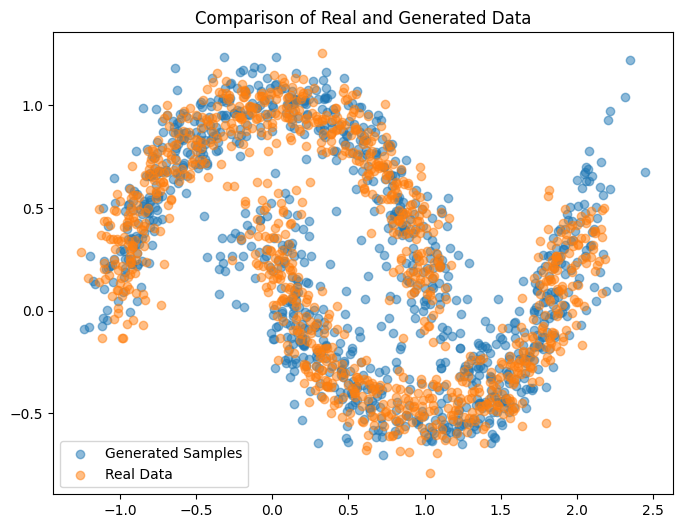

In [ ]:
# Sampling from the flow
with torch.no_grad():
    samples = flow.sample(1000).cpu().numpy()
    x_real, _ = make_moons(1000, noise=0.1)

    plt.figure(figsize=(8, 6))
    plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, label='Generated Samples')
    plt.scatter(x_real[:, 0], x_real[:, 1], alpha=0.5, label='Real Data')
    plt.legend()
    plt.title('Comparison of Real and Generated Data')
    plt.show()

# Section 2:Flows In Action

Here, we show how a flow can be trained to generate images with the `normflows` package. The flow is a [Glow](https://arxiv.org/abs/1807.03039) model, which is based on the [multi-scale architecture](https://arxiv.org/abs/1605.08803). This Glow model is applied to the MNIST dataset.

## Perparation

To get started, we have to install the `normflows` package.

In [1]:
!pip install normflows

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for normflows: filename=normflows-1.7.3-py2.py3-none-any.whl size=87247 sha256=0bea2b860fee8c98d84d6ea20aa673b89f640152eef9cbf05d8148ca418ee0f0
  Stored in directory: /root/.cache/pip/wheels/f7/b4/37/a3acc21799a058d6fe15127321dcdf99826f438bb591accafa
Successfully built normflows


In [2]:
# Import required packages
import torch
import torchvision as tv
import numpy as np
import normflows as nf

from matplotlib import pyplot as plt
from tqdm import tqdm
import os

Glow consists of `nf.flows.GlowBlocks`, that are arranged in a `nf.MultiscaleFlow`, following the multi-scale architecture. The base distribution is a `nf.distributions.DiagGaussian`, which is a diagonal Gaussian.

In [3]:
# Define the directory to save checkpoints
checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)


In [4]:
# Set up model (nothing TODO here)

# Define flows
L = 2
K = 16
torch.manual_seed(0)

input_shape = (1, 28, 28)
n_dims = np.prod(input_shape)
channels = 1
hidden_channels = 128
split_mode = 'channel'
scale = True

# Set up flows, distributions and merge operations
q0 = []
merges = []
flows = []
for i in range(L):
    flows_ = []
    for j in range(K):
        flows_ += [nf.flows.GlowBlock(channels * 2 ** (L + 1 - i), hidden_channels,
                                     split_mode=split_mode, scale=scale)]
    flows_ += [nf.flows.Squeeze()]
    flows += [flows_]
    if i > 0:
        merges += [nf.flows.Merge()]
        latent_shape = (input_shape[0] * 2 ** (L - i), input_shape[1] // 2 ** (L - i),
                        input_shape[2] // 2 ** (L - i))
    else:
        latent_shape = (input_shape[0] * 2 ** (L + 1), input_shape[1] // 2 ** L,
                        input_shape[2] // 2 ** L)
    q0 += [nf.distributions.DiagGaussian(latent_shape)]


# Construct flow model with the multiscale architecture
model = nf.MultiscaleFlow(q0, flows, merges)

/usr/local/lib/python3.12/dist-packages/torch/_tensor.py:923: UserWarning: torch.lu is deprecated in favor of torch.linalg.lu_factor / torch.linalg.lu_factor_ex and will be removed in a future PyTorch release.
LU, pivots = torch.lu(A, compute_pivots)
should be replaced with
LU, pivots = torch.linalg.lu_factor(A, compute_pivots)
and
LU, pivots, info = torch.lu(A, compute_pivots, get_infos=True)
should be replaced with
LU, pivots, info = torch.linalg.lu_factor_ex(A, compute_pivots) (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2064.)
  LU, pivots, infos = torch._lu_with_info(


In [5]:
# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
print(device)
model = model.to(device)

cuda


In [6]:
# @title loading MNIST dataset with TorchVision

batch_size = 128

transform = tv.transforms.Compose([tv.transforms.ToTensor(),
                                  #  nf.utils.Scale(255. / 256.),
                                   nf.utils.Jitter(1 / 256.)])

train_data = tv.datasets.MNIST('datasets/', train=True,
                                 download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True,
                                           drop_last=True)

test_data = tv.datasets.MNIST('datasets/', train=False,
                                download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 345kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.74MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.48MB/s]


## Training

Now, can train the model on the image data. you can change this code to your prefered style as long as it is correct and the result is reasonable.

In [7]:
# Train model
max_iter = 10000
save_every = 2000  # Save every 2000 iterations

loss_hist = np.array([])

optimizer = torch.optim.Adamax(model.parameters(), lr=1e-3, weight_decay=1e-5)

train_iter = iter(train_loader)

for i in tqdm(range(max_iter)):
    try:
        x, _ = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        x, _ = next(train_iter)

    x = x.to(device)

    # Zero gradients
    optimizer.zero_grad()

    # Forward pass: compute negative log likelihood using forward KLD
    loss = model.forward_kld(x)

    # Backward pass
    loss.backward()

    # Update parameters
    optimizer.step()

    loss_hist = np.append(loss_hist, loss.detach().to('cpu').numpy())

    # Save checkpoint periodically
    if (i + 1) % save_every == 0:
        checkpoint_path = os.path.join(checkpoint_dir, f'model_iter_{i+1}.pth')
        torch.save({
            'iteration': i + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss_hist': loss_hist,
        }, checkpoint_path)
        print(f'Checkpoint saved at iteration {i+1} to {checkpoint_path}')

 20%|██        | 2001/10000 [04:15<18:40,  7.14it/s]

Checkpoint saved at iteration 2000 to checkpoints/model_iter_2000.pth


 40%|████      | 4001/10000 [08:24<14:46,  6.77it/s]

Checkpoint saved at iteration 4000 to checkpoints/model_iter_4000.pth


 60%|██████    | 6001/10000 [12:36<11:52,  5.61it/s]

Checkpoint saved at iteration 6000 to checkpoints/model_iter_6000.pth


 80%|████████  | 8001/10000 [16:47<05:22,  6.19it/s]

Checkpoint saved at iteration 8000 to checkpoints/model_iter_8000.pth


100%|██████████| 10000/10000 [21:00<00:00,  7.93it/s]

Checkpoint saved at iteration 10000 to checkpoints/model_iter_10000.pth


In [8]:
# Save the final model after training
final_checkpoint_path = os.path.join(checkpoint_dir, 'model_final.pth')
torch.save({
    'iteration': max_iter,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss_hist': loss_hist,
}, final_checkpoint_path)
print(f'Final model saved to {final_checkpoint_path}')

Final model saved to checkpoints/model_final.pth


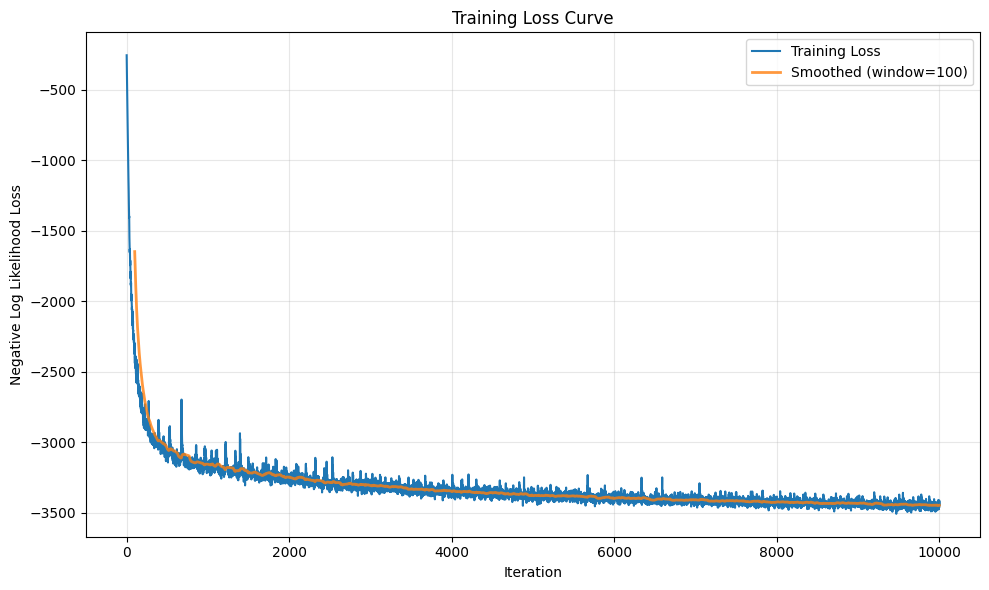

In [9]:
# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(loss_hist, label='Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Negative Log Likelihood Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)

# Add smoothing for better visualization (optional)
if len(loss_hist) > 100:
    # Apply moving average smoothing
    window_size = 100
    smoothed_loss = np.convolve(loss_hist, np.ones(window_size)/window_size, mode='valid')
    plt.plot(range(window_size-1, len(loss_hist)), smoothed_loss,
             label=f'Smoothed (window={window_size})', alpha=0.8, linewidth=2)
    plt.legend()

plt.tight_layout()
plt.show()

## Evaluation

To evaluate our model, we can just draw samples from our model.

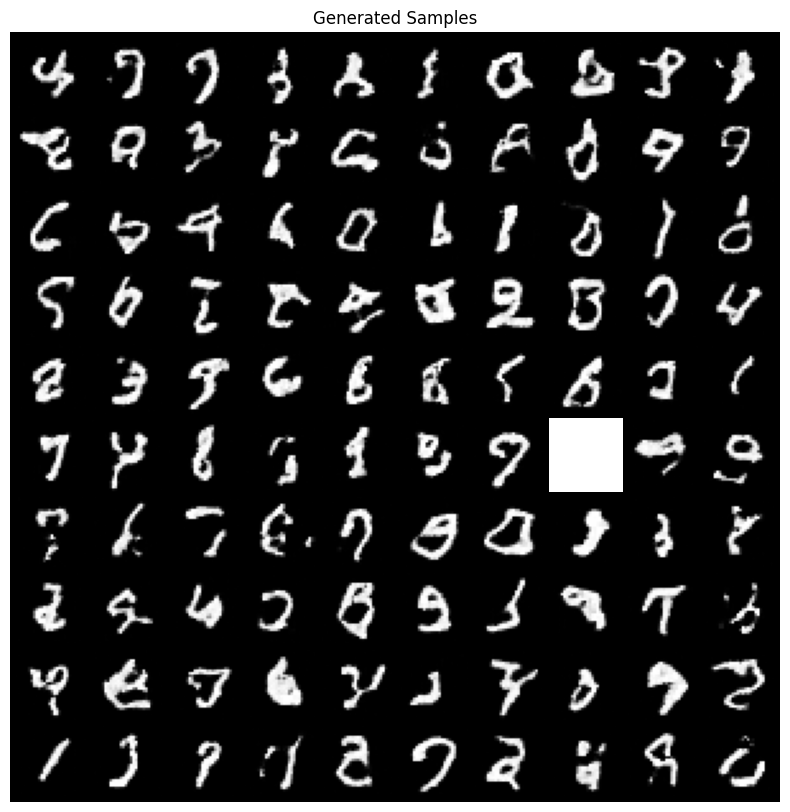

In [10]:
# Model samples
num_samples_per_grid = 10  # Number of samples per grid row
total_samples = num_samples_per_grid * num_samples_per_grid  # Total samples to generate


with torch.no_grad():
    # Sample from the base distribution
    x, _ = model.sample(num_samples_per_grid ** 2)  # No class labels needed
    x_ = torch.clamp(x, 0, 1)

    # Arrange samples in a grid
    grid = tv.utils.make_grid(x_, nrow=num_samples_per_grid)

    # Plot the grid of samples
    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(grid.cpu().numpy(), (1, 2, 0)))
    plt.axis('off')
    plt.title('Generated Samples')
    plt.show()

Note that to get competitive performance, a much larger model than specified in this notebook, which is trained over more iterations, is needed.

## In-Painting

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import torch.optim as optim

Now you are supposed to create a function that masks a random square of the image, and a function that fills the missing part based on maximum liklihood using the trained flow model.

In [32]:
def apply_random_square_mask(image, mask_size=8):
    """
    Applies a random square mask to the input image.

    Args:
        image (torch.Tensor): Input image tensor of shape [C, H, W].
        mask_size (int): Size of the square mask.

    Returns:
        masked_image (torch.Tensor): Image with the masked square.
        mask (torch.Tensor): Binary mask indicating masked regions (1 for masked).
    """
    C, H, W = image.shape
    masked_image = image.clone()

    # Sample a random top-left corner for the square
    top = torch.randint(0, H - mask_size + 1, (1,)).item()
    left = torch.randint(0, W - mask_size + 1, (1,)).item()

    # Create binary mask (1 for masked regions, 0 for visible regions)
    # Multi-channel mask to match image shape
    mask = torch.zeros_like(image[0])
    print(mask.shape)
    mask[ top:top+mask_size, left:left+mask_size] = 1

    # Apply the mask - set masked region to 0
    masked_image[:, top:top+mask_size, left:left+mask_size] = 0

    return masked_image, mask

In [33]:
# @title Optional random noise mask
def apply_random_noise_mask(image, noise_fraction=0.2):
    """
    Applies a random noise mask to the input image.

    Args:
        image (torch.Tensor): Input image tensor of shape [C, H, W].
        noise_fraction (float): Fraction of pixels to replace with noise.

    Returns:
        masked_image (torch.Tensor): Image with noise added.
        mask (torch.Tensor): Binary mask indicating noise regions (1 for noise).
    """
    masked_image = image.clone()
    mask = torch.zeros_like(image[0])  # Single channel mask

    C, H, W = image.shape
    num_pixels = H * W
    num_noise = int(noise_fraction * num_pixels)

    # Random indices
    noise_indices = np.random.choice(num_pixels, num_noise, replace=False)
    noise_coords = np.unravel_index(noise_indices, (H, W))

    # Apply noise
    for c in range(C):
        noise = torch.rand(num_noise) * 2 - 1  # Random noise in [-1, 1]
        masked_image[c, noise_coords[0], noise_coords[1]] = noise
    mask[noise_coords[0], noise_coords[1]] = 1.0

    return masked_image, mask


torch.Size([28, 28])


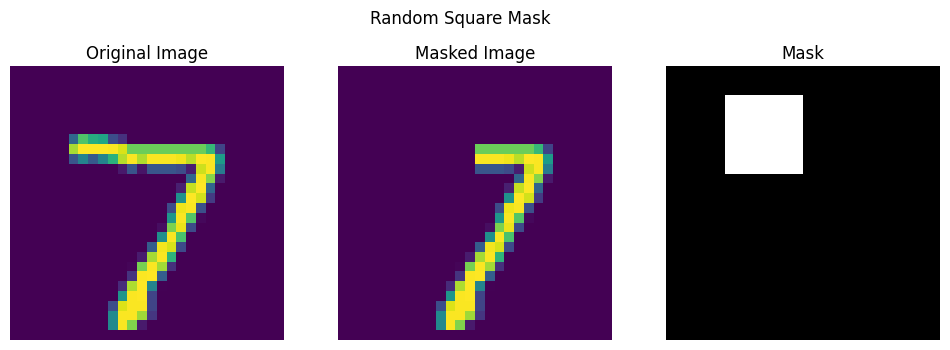

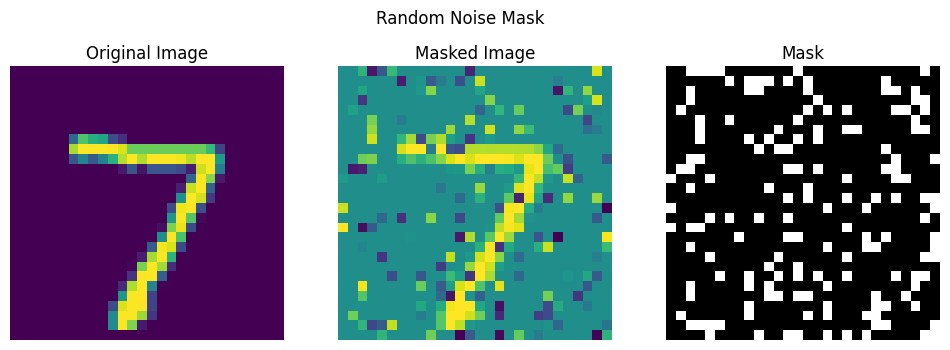

In [37]:
def visualize_masking(original_image, masked_image, mask, title="Masking Example"):
    """
    Visualizes the original, masked images and the mask.

    Args:
        original_image (torch.Tensor): Original image tensor [C, H, W].
        masked_image (torch.Tensor): Masked image tensor [C, H, W].
        mask (torch.Tensor): Binary mask [H, W].
        title (str): Title for the plot.
    """
    original = original_image.permute(1, 2, 0).cpu().numpy()
    masked = masked_image.permute(1, 2, 0).cpu().numpy()
    mask_display = mask.cpu().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(original)
    axs[0].set_title("Original Image")
    axs[0].axis('off')

    axs[1].imshow(masked)
    axs[1].set_title("Masked Image")
    axs[1].axis('off')

    axs[2].imshow(mask_display, cmap='gray')
    axs[2].set_title("Mask")
    axs[2].axis('off')

    plt.suptitle(title)
    plt.show()

# Example usage
# Assuming `sample_image` is a tensor [C, H, W] from your dataset
sample_image, _ = next(iter(test_loader))
sample_image = sample_image[0]  # Take the first image

masked_image_square, mask_square = apply_random_square_mask(sample_image, mask_size=8)
visualize_masking(sample_image, masked_image_square, mask_square, title="Random Square Mask")

masked_image_noise, mask_noise = apply_random_noise_mask(sample_image, noise_fraction=0.2)
visualize_masking(sample_image, masked_image_noise, mask_noise, title="Random Noise Mask")

In [38]:
def inpaint_image(model, masked_image, mask, device, num_steps=1000, lr=0.1):
    """
    Inpaints the masked regions of an image by maximizing the log-likelihood under the flow model.

    Args:
        model (nn.Module): Trained normalizing flow model.
        masked_image (torch.Tensor): Masked image tensor [C, H, W].
        mask (torch.Tensor): Binary mask tensor [H, W], 1 for masked pixels.
        device (torch.device): Device for computations.
        num_steps (int): Number of optimization steps.
        lr (float): Learning rate for the optimizer.

    Returns:
        inpainted_image (torch.Tensor): Inpainted image tensor [C, H, W].
    """
    model.eval()  # Set model to evaluation mode

    # Clone the masked image to avoid modifying the original
    inpainted_image = masked_image.clone().to(device).unsqueeze(0)  # Shape [1, C, H, W]
    mask = mask.unsqueeze(0).unsqueeze(0).to(device)  # Shape [1, 1, H, W]

    # Initialize the missing pixels to zeros (can also use random noise)
    # Create a tensor that will hold the missing pixels
    missing_pixels = torch.zeros_like(inpainted_image)  # Same shape as image

    # Make missing_pixels a learnable parameter
    missing_pixels = torch.nn.Parameter(missing_pixels)

    # Define optimizer
    optimizer = torch.optim.Adam([missing_pixels], lr=lr)

    for step in tqdm(range(num_steps), desc="Inpainting"):
        optimizer.zero_grad()

        # Reconstruct the full image by combining observed and missing pixels
        # Use mask to blend: observed pixels + learned missing pixels in masked regions
        reconstructed_image = inpainted_image * (1 - mask) + missing_pixels * mask

        # Compute negative log likelihood loss
        loss = model.forward_kld(reconstructed_image)

        # Backpropagation
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            # Clamp the missing pixels to valid range [0, 1] for images
            missing_pixels.data.clamp_(0, 1)

        if (step + 1) % 100 == 0:
            print(f"Step [{step+1}/{num_steps}], Loss: {loss.item():.4f}")

    # Final reconstruction with optimized missing pixels
    with torch.no_grad():
        inpainted_image = inpainted_image * (1 - mask) + missing_pixels * mask
        inpainted_image = inpainted_image.squeeze(0)  # Remove batch dimension

    return inpainted_image

In [39]:
# Example usage with a batch of 4 images
batch_size = 4
sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:batch_size]
sample_labels = sample_labels[:batch_size]

# Apply random square masks to the batch
masked_images = []
masks = []
inpainted_images = []

for img in sample_images:
    masked_img, mask = apply_random_square_mask(img, mask_size=8)
    masked_images.append(masked_img)
    masks.append(mask)
    inpainted_images.append(inpaint_image(model, masked_img, mask, device, num_steps=1000, lr=0.1))

masked_images = torch.stack(masked_images)
masks = torch.stack(masks)
inpainted_images = torch.stack(inpainted_images)

torch.Size([28, 28])


Inpainting:  10%|█         | 101/1000 [00:09<01:17, 11.62it/s]

Step [100/1000], Loss: -3294.0908


Inpainting:  20%|██        | 201/1000 [00:18<01:09, 11.51it/s]

Step [200/1000], Loss: -3355.4312


...

Step [800/1000], Loss: -3221.3977


Inpainting:  90%|█████████ | 902/1000 [01:23<00:08, 11.73it/s]

Step [900/1000], Loss: -3230.8174


Inpainting: 100%|██████████| 1000/1000 [01:32<00:00, 10.86it/s]

Step [1000/1000], Loss: -3241.6951


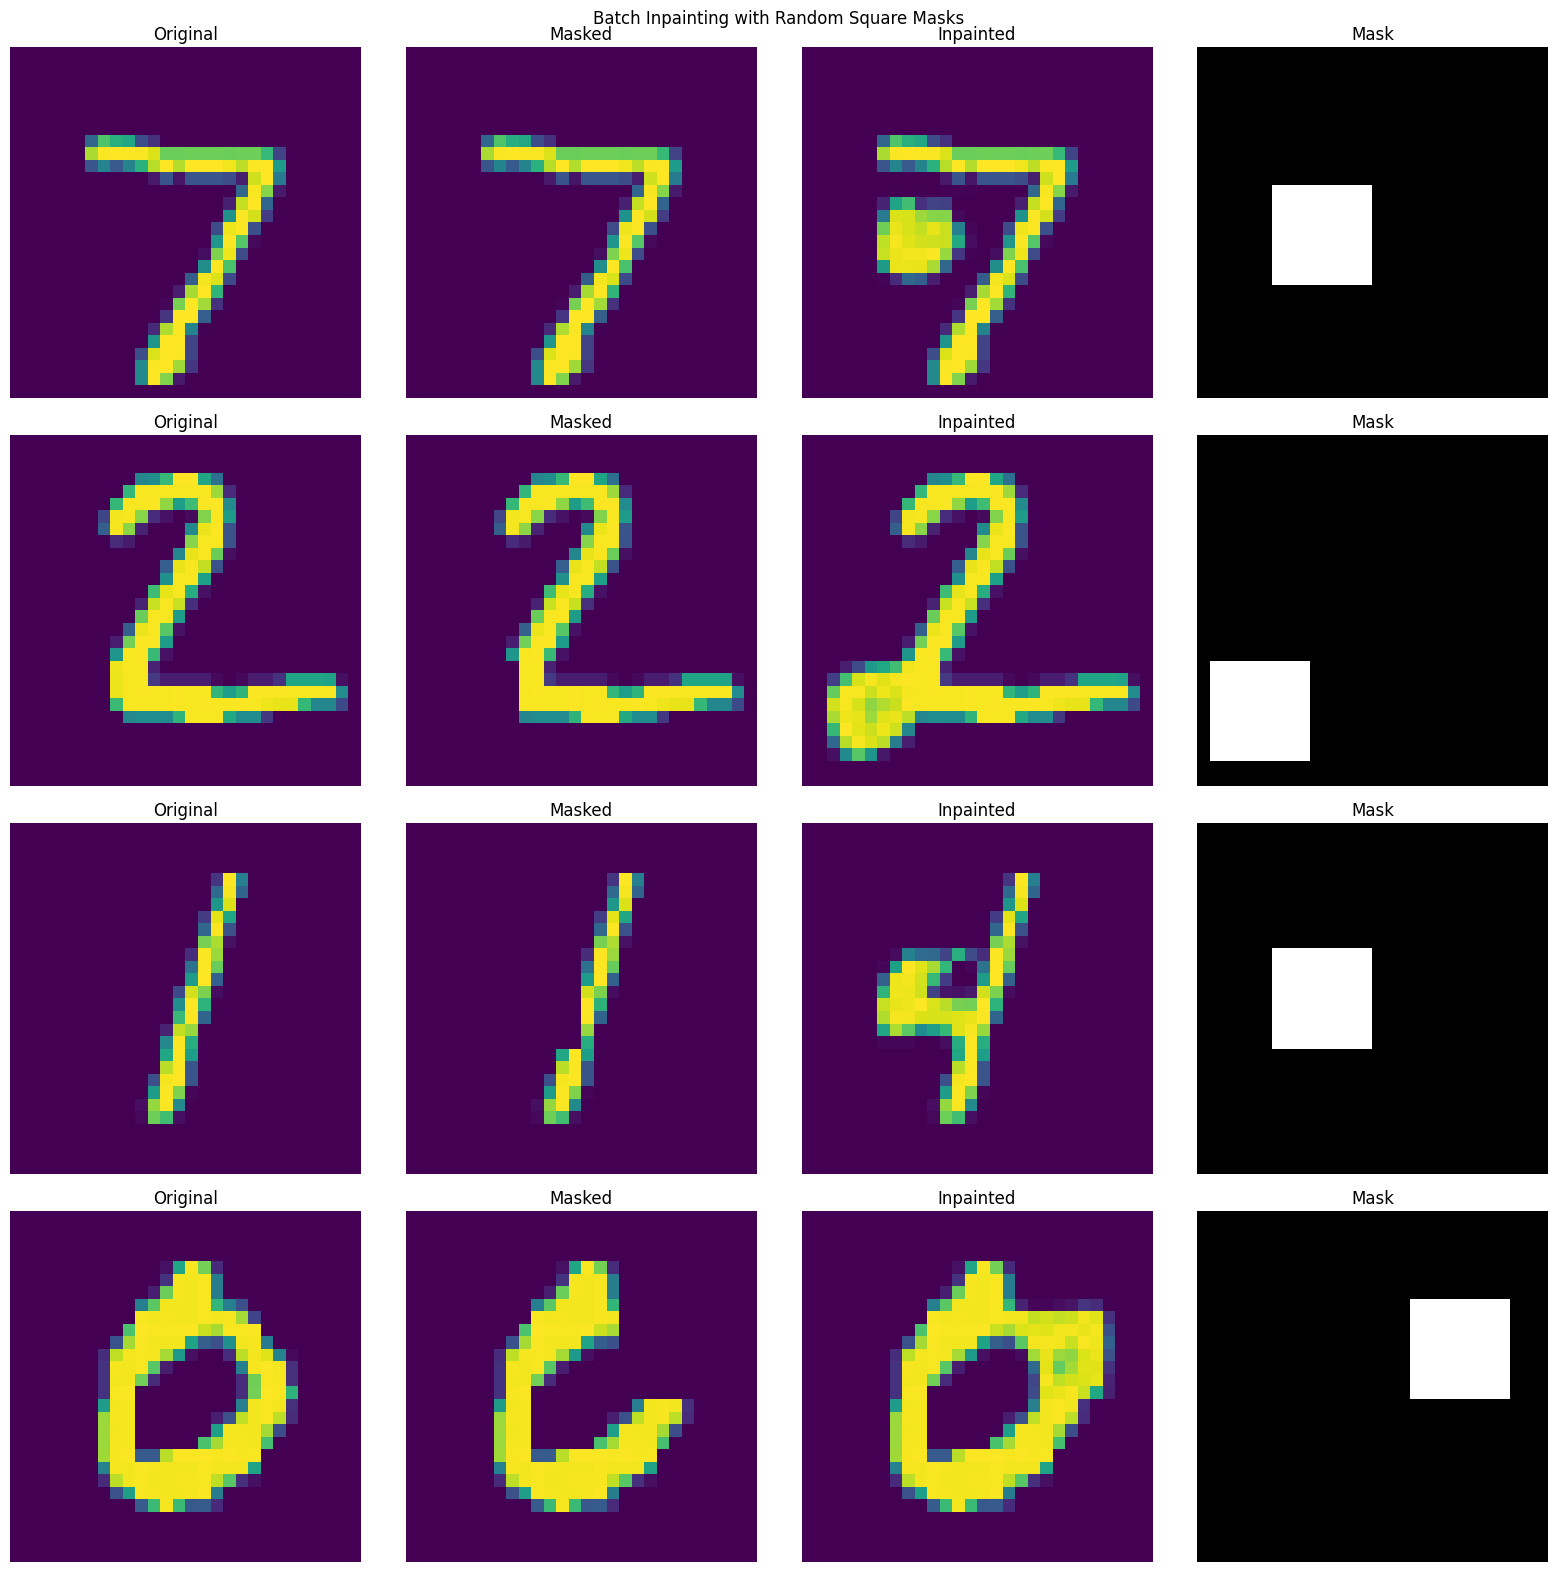

In [40]:
# Visualize the results (this is a suggested code, you can change this)
def visualize_batch_inpainting(originals, masked, inpainted, masks, title="Batch Inpainting Results"):
    """
    Visualizes a batch of original, masked, and inpainted images with their masks.

    Args:
        originals (torch.Tensor): Original images [N, C, H, W].
        masked (torch.Tensor): Masked images [N, C, H, W].
        inpainted (torch.Tensor): Inpainted images [N, C, H, W].
        masks (torch.Tensor): Masks [N, H, W].
        title (str): Title for the plot.
    """
    N = originals.size(0)
    fig, axs = plt.subplots(N, 4, figsize=(16, 4 * N))

    for i in range(N):

        original = originals[i].permute(1, 2, 0).detach().cpu().numpy()
        masked_img = masked[i].permute(1, 2, 0).detach().cpu().numpy()
        inpainted_img = inpainted[i].permute(1, 2, 0).detach().cpu().numpy()
        mask_display = masks[i].detach().cpu().numpy()

        axs[i, 0].imshow(original)
        axs[i, 0].set_title("Original")
        axs[i, 0].axis('off')

        axs[i, 1].imshow(masked_img)
        axs[i, 1].set_title("Masked")
        axs[i, 1].axis('off')

        axs[i, 2].imshow(inpainted_img)
        axs[i, 2].set_title("Inpainted")
        axs[i, 2].axis('off')

        axs[i, 3].imshow(mask_display, cmap='gray')
        axs[i, 3].set_title("Mask")
        axs[i, 3].axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

visualize_batch_inpainting(sample_images, masked_images, inpainted_images, masks, title="Batch Inpainting with Random Square Masks")
